# Milestone 3 — Robustness, Adversarial Testing & Monitoring

---
## train

### Multi-Label API Call Classifier — Training Pipeline

Architecture: 1D-CNN + BiLSTM hybrid for multi-label classification

Input:  code context (tokenized character/subword sequence)
Output: 5-dim sigmoid → [file_access, network_access, process_mgmt, pure_calculation, code_execution]

Usage:
    # Quick baseline first (TF-IDF + Logistic Regression):
    python train.py --mode baseline --data-dir ./training_data

    # Train CNN+LSTM:
    python train.py --mode train --data-dir ./training_data --epochs 20

    # Resume training:
    python train.py --mode train --data-dir ./training_data --resume checkpoints/best_model.pt

    # Evaluate:
    python train.py --mode eval --data-dir ./training_data --resume checkpoints/best_model.pt

    # Predict on new code:
    python train.py --mode predict --resume checkpoints/best_model.pt \
        --text "gen_rpc_ops.rpc_call(client, payload, [tf.constant(2)], 100000)"

In [1]:
import os

# ROCm fix: gfx1035 (RDNA2 APU) is not in PyTorch ROCm 6.2's precompiled kernel set.
# Override to gfx1030 (binary-compatible RDNA2) so HIP can find compiled kernels.
# TORCH_BLAS_PREFER_HIPBLASLT=0 disables hipBLASLt which fails on this GPU.
os.environ.setdefault('HSA_OVERRIDE_GFX_VERSION', '10.3.0')
os.environ.setdefault('TORCH_BLAS_PREFER_HIPBLASLT', '0')

import json
import time
import logging
import argparse
import numpy as np
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

#### Constants

In [2]:
LABELS = ["file_access", "network_access", "process_mgmt", "pure_calculation", "code_execution"]
NUM_LABELS = len(LABELS)

#### Tokenizer — Character-level with code-aware special tokens

In [3]:
class CodeTokenizer:
    """
    Character-level tokenizer with code-aware token merging.

    Why character-level:
    - API paths have meaningful sub-word structure (gen_rpc_ops → gen, rpc, ops)
    - No need for a pretrained vocabulary
    - Works across all three frameworks without modification
    - Handles unseen function names gracefully

    Special tokens capture code structure:
    - Punctuation groups: (), [], {}, .,  =, etc.
    - Whitespace normalization
    - Number collapsing (all digits → 0)
    """

    PAD = 0
    UNK = 1
    BOS = 2
    EOS = 3
    SPECIAL_OFFSET = 4

    def __init__(self, max_vocab_size=300, max_length=512):
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.fitted = False

    def fit(self, texts: list[str]):
        """Build vocabulary from training texts."""
        char_counts = Counter()
        for text in texts:
            text = self._normalize(text)
            char_counts.update(text)

        # Take top characters by frequency
        most_common = char_counts.most_common(self.max_vocab_size - self.SPECIAL_OFFSET)
        self.char_to_idx = {
            "<PAD>": self.PAD,
            "<UNK>": self.UNK,
            "<BOS>": self.BOS,
            "<EOS>": self.EOS,
        }
        for i, (char, _) in enumerate(most_common):
            self.char_to_idx[char] = i + self.SPECIAL_OFFSET

        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}
        self.vocab_size = len(self.char_to_idx)
        self.fitted = True

        logger.info(f"Tokenizer fitted: vocab_size={self.vocab_size}, max_length={self.max_length}")

    def encode(self, text: str) -> list[int]:
        """Encode text to token indices."""
        text = self._normalize(text)
        tokens = [self.BOS]
        for char in text[:self.max_length - 2]:
            tokens.append(self.char_to_idx.get(char, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def encode_padded(self, text: str) -> tuple[list[int], int]:
        """Encode and pad to max_length. Returns (tokens, actual_length)."""
        tokens = self.encode(text)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[:self.max_length]
            length = self.max_length
        return tokens, length

    def _normalize(self, text: str) -> str:
        """Normalize code text for tokenization."""
        # Collapse consecutive whitespace
        import re
        text = re.sub(r'\s+', ' ', text)
        # Collapse numbers to single digit (123 → 0, 10000 → 0)
        text = re.sub(r'\d+', '0', text)
        # Lowercase for consistency
        text = text.lower()
        return text.strip()

    def save(self, path: str):
        data = {
            "char_to_idx": self.char_to_idx,
            "max_length": self.max_length,
            "vocab_size": self.vocab_size,
        }
        with open(path, "w") as f:
            json.dump(data, f)

    def load(self, path: str):
        with open(path, "r") as f:
            data = json.load(f)
        self.char_to_idx = data["char_to_idx"]
        self.idx_to_char = {int(v): k for k, v in self.char_to_idx.items()}
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True

#### Syscall Tokenizer — word-level, one token per syscall name

In [4]:
class SyscallTokenizer:
    """
    Word-level tokenizer for system call sequences.

    Each space-separated token is treated as a single syscall name (e.g. 'read',
    'write', 'open', 'socket', 'fork').  This gives the model a direct semantic
    handle on OS-level behavior rather than character patterns in source code.

    Vocabulary is small (~300-400 Linux/Windows syscall names) so max_vocab_size
    of 512 is almost always enough to cover every syscall seen in training.
    """

    PAD = 0
    UNK = 1
    BOS = 2
    EOS = 3
    SPECIAL_OFFSET = 4

    def __init__(self, max_vocab_size: int = 512, max_length: int = 256):
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        self.token_to_idx: dict[str, int] = {}
        self.idx_to_token: dict[int, str] = {}
        self.vocab_size: int = 0
        self.fitted: bool = False

    # ── Fitting ──

    def fit(self, texts: list[str]):
        """Build vocabulary from training syscall sequences."""
        counts: Counter = Counter()
        for text in texts:
            counts.update(self._tokenize(text))

        most_common = counts.most_common(self.max_vocab_size - self.SPECIAL_OFFSET)
        self.token_to_idx = {
            "<PAD>": self.PAD,
            "<UNK>": self.UNK,
            "<BOS>": self.BOS,
            "<EOS>": self.EOS,
        }
        for i, (tok, _) in enumerate(most_common):
            self.token_to_idx[tok] = i + self.SPECIAL_OFFSET

        self.idx_to_token = {v: k for k, v in self.token_to_idx.items()}
        self.vocab_size = len(self.token_to_idx)
        self.fitted = True
        logger.info(f"SyscallTokenizer fitted: vocab_size={self.vocab_size}, max_length={self.max_length}")

    def _tokenize(self, text: str) -> list[str]:
        """Split space-separated syscall sequence into individual names."""
        return [t.lower() for t in text.split() if t.strip()]

    # ── Encoding ──

    def encode(self, text: str) -> list[int]:
        tokens = [self.BOS]
        for tok in self._tokenize(text)[: self.max_length - 2]:
            tokens.append(self.token_to_idx.get(tok, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def encode_padded(self, text: str) -> tuple[list[int], int]:
        tokens = self.encode(text)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[: self.max_length]
            length = self.max_length
        return tokens, length

    # ── Persistence ──

    def save(self, path: str):
        with open(path, "w") as f:
            json.dump(
                {
                    "type": "syscall",
                    "token_to_idx": self.token_to_idx,
                    "max_length": self.max_length,
                    "vocab_size": self.vocab_size,
                },
                f,
            )

    def load(self, path: str):
        with open(path, "r") as f:
            data = json.load(f)
        self.token_to_idx = data["token_to_idx"]
        self.idx_to_token = {int(v): k for k, v in self.token_to_idx.items()}
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True


def load_tokenizer(path: str, tokenizer_type: str, max_length: int):
    """Instantiate and load the right tokenizer from a saved file."""
    if tokenizer_type == "syscall":
        tok = SyscallTokenizer(max_length=max_length)
    else:
        tok = CodeTokenizer(max_length=max_length)
    tok.load(path)
    return tok

#### Dataset

In [5]:
class APICallDataset(Dataset):
    """PyTorch dataset for API call classification."""

    def __init__(self, jsonl_path: str, tokenizer: CodeTokenizer, path_tokenizer=None):
        self.tokenizer = tokenizer
        self.path_tokenizer = path_tokenizer  # CodeTokenizer for api_path; None = single-input mode
        self.records = []

        with open(jsonl_path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                line = line.strip()
                if line:
                    self.records.append(json.loads(line))

        logger.info(f"Loaded {len(self.records)} records from {jsonl_path}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        text = r.get("text", "")
        label_vector = r.get("label_vector", [0] * NUM_LABELS)

        tokens, length = self.tokenizer.encode_padded(text)

        item = {
            "input_ids": torch.tensor(tokens, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "labels": torch.tensor(label_vector, dtype=torch.float32),
        }

        if self.path_tokenizer is not None:
            api_path = r.get("api_path", "")
            path_tokens, path_length = self.path_tokenizer.encode_padded(api_path)
            item["path_ids"] = torch.tensor(path_tokens, dtype=torch.long)
            item["path_length"] = torch.tensor(path_length, dtype=torch.long)

        return item

    def get_texts(self):
        """Return all syscall texts for tokenizer fitting."""
        return [r.get("text", "") for r in self.records]

    def get_api_paths(self):
        """Return all api_path strings for path tokenizer fitting."""
        return [r.get("api_path", "") for r in self.records]

#### Model: 1D-CNN + BiLSTM

In [6]:
class CNNBiLSTMClassifier(nn.Module):
    """
    1D-CNN + Bidirectional LSTM for multi-label code classification.

    Architecture:
        Input (char indices)
          → Embedding (learnable, dim=64)
          → 1D-CNN (3 filter sizes: 3, 5, 7) extracting local patterns
          → BiLSTM (captures long-range sequential dependencies)
          → Attention pooling (focuses on most discriminative parts)
          → FC layers → Sigmoid (5 labels)

    The CNN finds local motifs like "gen_rpc", "torch.save", ".load(".
    The BiLSTM reads the sequence of CNN features to understand context.
    Attention lets the model focus on the API call itself vs. surrounding code.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        cnn_filters: int = 128,
        cnn_kernel_sizes: tuple = (3, 5, 7),
        lstm_hidden: int = 128,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        num_labels: int = NUM_LABELS,
    ):
        super().__init__()

        self.embed_dim = embed_dim

        # Embedding
        # ROCm/HIP embedding kernels require num_embeddings to be a multiple of
        # the wavefront size (64 on AMD GPUs).  Padding to ≥256 avoids
        # "invalid device function" errors when vocab_size is small (e.g. syscall
        # tokenizer produces vocab_size ~86).  Extra rows are never indexed.
        effective_vocab_size = max(vocab_size, 256)
        self.embedding = nn.Embedding(effective_vocab_size, embed_dim, padding_idx=0)

        # Multi-scale 1D CNN
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])

        cnn_out_dim = cnn_filters * len(cnn_kernel_sizes)

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )

        lstm_out_dim = lstm_hidden * 2  # bidirectional

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(lstm_out_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, num_labels),
        )

    def forward(self, input_ids, lengths=None):
        # Embed: (batch, seq_len) → (batch, seq_len, embed_dim)
        # Use direct weight indexing instead of F.embedding — dispatches through
        # the index_cuda kernel rather than embedding_forward_cuda, which avoids
        # a cold-start "invalid device function" error on ROCm/RDNA2 (gfx1030).
        x = self.embedding.weight[input_ids]

        # CNN expects (batch, channels, seq_len)
        x_cnn = x.permute(0, 2, 1)

        # Multi-scale CNN features
        conv_outputs = [conv(x_cnn) for conv in self.convs]
        # Concatenate: (batch, cnn_filters * n_kernels, seq_len)
        x = torch.cat(conv_outputs, dim=1)
        # Back to (batch, seq_len, features)
        x = x.permute(0, 2, 1)

        # Pack for LSTM if lengths provided
        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.lstm(x)

        # Attention pooling
        attn_weights = self.attention(lstm_out)  # (batch, seq_len, 1)

        # Mask padding positions
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_weights = attn_weights.masked_fill(mask.unsqueeze(2), float('-inf'))

        attn_weights = torch.softmax(attn_weights, dim=1)
        # Weighted sum: (batch, lstm_out_dim)
        context = (lstm_out * attn_weights).sum(dim=1)

        # Classify
        logits = self.classifier(context)
        return logits

#### Dual-Input Model: syscall sequence + API path

In [7]:
class DualInputClassifier(nn.Module):
    """
    Dual-input classifier: syscall sequence + API path text → multi-label predictions.

    Syscall branch (word-level):
        word ids → Embedding → 3×CNN → BiLSTM → Attention pooling → syscall_ctx

    API path branch (char-level, no LSTM — paths are short strings):
        char ids → Embedding → 3×CNN → Max pooling → path_ctx

    Output: concat(syscall_ctx, path_ctx) → FC layers → num_labels

    Why separate branches:
    - Syscalls carry runtime OS-behavior signal (strace-derived)
    - API path carries semantic naming signal ("save" → file, "fork" → process)
    - 99.6% of syscall signatures are shared across labels — path resolves ambiguity
    """

    def __init__(
        self,
        syscall_vocab_size: int,
        path_vocab_size: int,
        embed_dim: int = 64,
        cnn_filters: int = 64,
        cnn_kernel_sizes: tuple = (3, 5, 7),
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        num_labels: int = NUM_LABELS,
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.syscall_vocab_size = syscall_vocab_size
        self.path_vocab_size = path_vocab_size

        # ── Syscall branch ────────────────────────────────────────────────────
        # Same architecture as CNNBiLSTMClassifier.
        effective_syscall_vocab = max(syscall_vocab_size, 256)
        self.syscall_embedding = nn.Embedding(effective_syscall_vocab, embed_dim, padding_idx=0)

        self.syscall_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])
        syscall_cnn_dim = cnn_filters * len(cnn_kernel_sizes)

        self.syscall_lstm = nn.LSTM(
            input_size=syscall_cnn_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )
        syscall_lstm_dim = lstm_hidden * 2

        self.syscall_attn = nn.Sequential(
            nn.Linear(syscall_lstm_dim, syscall_lstm_dim // 2),
            nn.Tanh(),
            nn.Linear(syscall_lstm_dim // 2, 1),
        )

        # ── API path branch (char-level CNN) ──────────────────────────────────
        # Lighter branch — API paths are short (~10–50 chars), no LSTM needed.
        path_embed_dim = 32
        path_cnn_filters = max(cnn_filters // 2, 32)
        effective_path_vocab = max(path_vocab_size, 256)
        self.path_embedding = nn.Embedding(effective_path_vocab, path_embed_dim, padding_idx=0)

        self.path_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(path_embed_dim, path_cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(path_cnn_filters),
                nn.ReLU(),
            )
            for ks in cnn_kernel_sizes
        ])
        path_out_dim = path_cnn_filters * len(cnn_kernel_sizes)

        # ── Fused classifier ──────────────────────────────────────────────────
        fused_dim = syscall_lstm_dim + path_out_dim
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(fused_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(fused_dim // 2, num_labels),
        )

    def _encode_syscalls(self, syscall_ids, lengths=None):
        x = self.syscall_embedding.weight[syscall_ids]
        x = x.permute(0, 2, 1)
        conv_outs = [conv(x) for conv in self.syscall_convs]
        x = torch.cat(conv_outs, dim=1).permute(0, 2, 1)

        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.syscall_lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.syscall_lstm(x)

        attn_w = self.syscall_attn(lstm_out)
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_w = attn_w.masked_fill(mask.unsqueeze(2), float('-inf'))
        attn_w = torch.softmax(attn_w, dim=1)
        return (lstm_out * attn_w).sum(dim=1)

    def _encode_path(self, path_ids):
        x = self.path_embedding.weight[path_ids]
        x = x.permute(0, 2, 1)
        # Global max pool over time for each kernel
        pooled = [conv(x).max(dim=2).values for conv in self.path_convs]
        return torch.cat(pooled, dim=1)

    def forward(self, syscall_ids, path_ids, syscall_lengths=None):
        syscall_ctx = self._encode_syscalls(syscall_ids, syscall_lengths)
        path_ctx = self._encode_path(path_ids)
        combined = torch.cat([syscall_ctx, path_ctx], dim=1)
        return self.classifier(combined)

#### Metrics

In [8]:
class MultiLabelMetrics:
    """Track per-label and aggregate metrics for multi-label classification."""

    def __init__(self, label_names=LABELS, threshold=0.5):
        self.label_names = label_names
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.all_preds = []
        self.all_labels = []

    def update(self, logits: torch.Tensor, labels: torch.Tensor):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).cpu().numpy()
        labels = labels.cpu().numpy()
        self.all_preds.append(preds)
        self.all_labels.append(labels)

    def compute(self) -> dict:
        preds = np.concatenate(self.all_preds, axis=0)
        labels = np.concatenate(self.all_labels, axis=0)

        results = {}
        f1s = []

        for i, name in enumerate(self.label_names):
            tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum()
            tn = ((preds[:, i] == 0) & (labels[:, i] == 0)).sum()

            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-8)
            accuracy = (tp + tn) / max(tp + fp + fn + tn, 1)

            results[name] = {
                "precision": round(float(precision), 4),
                "recall": round(float(recall), 4),
                "f1": round(float(f1), 4),
                "accuracy": round(float(accuracy), 4),
                "support": int(labels[:, i].sum()),
            }
            f1s.append(f1)

        # Aggregate
        results["macro_f1"] = round(float(np.mean(f1s)), 4)
        results["exact_match"] = round(float((preds == labels).all(axis=1).mean()), 4)

        # Hamming loss
        results["hamming_loss"] = round(float((preds != labels).mean()), 4)

        return results

    def print_report(self, results: dict):
        logger.info(f"\n{'Label':>20s}  {'Prec':>6s}  {'Rec':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>8s}")
        logger.info("-" * 65)
        for name in self.label_names:
            r = results[name]
            logger.info(
                f"{name:>20s}  {r['precision']:6.3f}  {r['recall']:6.3f}  "
                f"{r['f1']:6.3f}  {r['accuracy']:6.3f}  {r['support']:>8d}"
            )
        logger.info("-" * 65)
        logger.info(f"{'Macro F1':>20s}  {'':>6s}  {'':>6s}  {results['macro_f1']:6.3f}")
        logger.info(f"{'Exact Match':>20s}  {'':>6s}  {'':>6s}  {results['exact_match']:6.3f}")
        logger.info(f"{'Hamming Loss':>20s}  {'':>6s}  {'':>6s}  {results['hamming_loss']:6.4f}")

#### Training Loop

In [9]:
class Trainer:

    def __init__(self, model, train_loader, val_loader, args, class_weights=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.args = args
        self.device = torch.device(args.device)
        self.model.to(self.device)

        # Loss with class weights
        if class_weights is not None:
            pos_weight = torch.tensor(class_weights, dtype=torch.float32).to(self.device)
            self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            logger.info(f"Using weighted BCE loss: {class_weights}")
        else:
            self.criterion = nn.BCEWithLogitsLoss()

        # Optimizer
        self.optimizer = optim.AdamW(
            model.parameters(),
            lr=args.lr,
            weight_decay=args.weight_decay,
        )

        # Scheduler: cosine annealing with warmup
        total_steps = len(train_loader) * args.epochs
        warmup_steps = int(total_steps * 0.1)
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=args.lr,
            total_steps=total_steps,
            pct_start=warmup_steps / total_steps,
            anneal_strategy='cos',
        )

        self.metrics = MultiLabelMetrics()
        self.best_f1 = 0.0
        self.patience_counter = 0

        # Checkpoint directory
        self.ckpt_dir = Path(args.checkpoint_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        # ROCm/HIP cold-start warmup: force JIT kernel compilation for every
        # layer type before the training loop begins.  Without this, the very
        # first real batch triggers an asynchronous "invalid device function"
        # error on some AMD GPUs (e.g. gfx1030/RDNA2 with ROCm 6.2).
        #
        # IMPORTANT: create tensors on CPU then .to(device) — this uses
        # hipMemcpy (a plain memory copy, no kernel).  Do NOT use the
        # device= constructor arg here; that calls a HIP fill kernel which
        # is itself the first operation that fails on a cold GPU.
        if self.device.type == "cuda":
            # ROCm cold-start fix: on some AMD GPUs (e.g. gfx1030/RDNA2 with
            # ROCm 6.2), the first kernel launch in a fresh Python process fails
            # with "invalid device function" because HIP JIT-compiles kernels
            # lazily and the first attempt races against the compiler.  The
            # failed attempt still caches the compiled kernel on disk, so the
            # RETRY succeeds.  We loop up to 3 times; typical fix is attempt 2.
            for _attempt in range(3):
                try:
                    # Primitive op first to open the compute pipeline.
                    _f = torch.ones(4, 4).to(self.device) * 2.0
                    torch.cuda.synchronize()
                    del _f
                    # Full forward + backward to compile every layer's kernel.
                    _ids = torch.zeros(2, 4, dtype=torch.long).to(self.device)
                    _lbs = torch.zeros(2, NUM_LABELS).to(self.device)
                    if isinstance(model, DualInputClassifier):
                        _pids = torch.zeros(2, 4, dtype=torch.long).to(self.device)
                        _logits = model(_ids, _pids)
                        del _pids
                    else:
                        _logits = model(_ids)
                    _loss = self.criterion(_logits, _lbs)
                    _loss.backward()
                    self.optimizer.zero_grad()
                    torch.cuda.synchronize()
                    del _ids, _lbs, _logits, _loss
                    break  # warmup succeeded
                except RuntimeError as _e:
                    if "HIP error" not in str(_e) and "invalid device function" not in str(_e):
                        raise  # not a cold-start error — propagate
                    # Clear any partial gradients left by the failed pass
                    for _p in model.parameters():
                        _p.grad = None
                    if _attempt == 2:
                        logger.warning("GPU warmup failed after 3 attempts — proceeding anyway")
                    else:
                        logger.info(f"ROCm cold-start on warmup attempt {_attempt + 1}, retrying...")

    def train(self):
        logger.info(f"\nStarting training for {self.args.epochs} epochs")
        logger.info(f"Device: {self.device}")
        logger.info(f"Train batches: {len(self.train_loader)}, Val batches: {len(self.val_loader)}")

        for epoch in range(1, self.args.epochs + 1):
            # Train
            train_loss = self._train_epoch(epoch)

            # Validate
            val_results, val_loss = self._validate()

            # Log
            lr = self.optimizer.param_groups[0]['lr']
            logger.info(
                f"Epoch {epoch}/{self.args.epochs} — "
                f"train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, "
                f"macro_f1: {val_results['macro_f1']:.4f}, "
                f"exact_match: {val_results['exact_match']:.4f}, "
                f"lr: {lr:.6f}"
            )

            # Per-label F1
            for name in LABELS:
                r = val_results[name]
                logger.info(f"  {name:>20s}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f}")

            # Save best
            if val_results["macro_f1"] > self.best_f1:
                self.best_f1 = val_results["macro_f1"]
                self.patience_counter = 0
                self._save_checkpoint(epoch, val_results, is_best=True)
                logger.info(f"  ★ New best macro F1: {self.best_f1:.4f}")
            else:
                self.patience_counter += 1

            # Save periodic
            if epoch % 5 == 0:
                self._save_checkpoint(epoch, val_results, is_best=False)

            # Early stopping
            if self.patience_counter >= self.args.patience:
                logger.info(f"Early stopping after {self.args.patience} epochs without improvement")
                break

        logger.info(f"\nTraining complete. Best macro F1: {self.best_f1:.4f}")

    def _train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch_idx, batch in enumerate(self.train_loader):
            input_ids = batch["input_ids"].to(self.device)
            lengths = batch["length"].to(self.device)
            labels = batch["labels"].to(self.device)

            self.optimizer.zero_grad()
            if isinstance(self.model, DualInputClassifier):
                path_ids = batch["path_ids"].to(self.device)
                logits = self.model(input_ids, path_ids, lengths)
            else:
                logits = self.model(input_ids, lengths)
            loss = self.criterion(logits, labels)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()
            num_batches += 1

            if batch_idx > 0 and batch_idx % 100 == 0:
                avg_loss = total_loss / num_batches
                logger.info(f"  Epoch {epoch} [{batch_idx}/{len(self.train_loader)}] loss: {avg_loss:.4f}")

        return total_loss / max(num_batches, 1)

    @torch.no_grad()
    def _validate(self):
        self.model.eval()
        self.metrics.reset()
        total_loss = 0
        num_batches = 0

        for batch in self.val_loader:
            input_ids = batch["input_ids"].to(self.device)
            lengths = batch["length"].to(self.device)
            labels = batch["labels"].to(self.device)

            if isinstance(self.model, DualInputClassifier):
                path_ids = batch["path_ids"].to(self.device)
                logits = self.model(input_ids, path_ids, lengths)
            else:
                logits = self.model(input_ids, lengths)
            loss = self.criterion(logits, labels)

            self.metrics.update(logits, labels)
            total_loss += loss.item()
            num_batches += 1

        results = self.metrics.compute()
        return results, total_loss / max(num_batches, 1)

    def _save_checkpoint(self, epoch, results, is_best=False):
        if isinstance(self.model, DualInputClassifier):
            model_config = {
                "dual_input": True,
                "syscall_vocab_size": self.model.syscall_vocab_size,
                "path_vocab_size": self.model.path_vocab_size,
                "embed_dim": self.model.embed_dim,
            }
        else:
            model_config = {
                "dual_input": False,
                "vocab_size": self.model.embedding.num_embeddings,
                "embed_dim": self.model.embed_dim,
            }
        state = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "best_f1": self.best_f1,
            "results": results,
            "config": model_config,
        }

        if is_best:
            path = self.ckpt_dir / "best_model.pt"
        else:
            path = self.ckpt_dir / f"checkpoint_epoch_{epoch}.pt"

        torch.save(state, path)
        logger.info(f"  Saved checkpoint to {path}")

#### Baseline: TF-IDF + Logistic Regression

In [10]:
def run_baseline(data_dir: str):
    """Quick baseline to sanity-check data quality."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.metrics import classification_report

    logger.info("=" * 60)
    logger.info("BASELINE: TF-IDF + Logistic Regression")
    logger.info("=" * 60)

    # Load
    def load_split(path):
        texts, labels = [], []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                r = json.loads(line.strip())
                texts.append(r.get("text", ""))
                labels.append(r.get("label_vector", [0] * NUM_LABELS))
        return texts, np.array(labels)

    train_texts, train_labels = load_split(os.path.join(data_dir, "train.jsonl"))
    val_texts, val_labels = load_split(os.path.join(data_dir, "val.jsonl"))
    test_texts, test_labels = load_split(os.path.join(data_dir, "test.jsonl"))

    logger.info(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

    # TF-IDF with character n-grams (captures sub-word code patterns)
    logger.info("Fitting TF-IDF (char n-grams 2-5)...")
    tfidf = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        max_features=50000,
        sublinear_tf=True,
    )
    X_train = tfidf.fit_transform(train_texts)
    X_val = tfidf.transform(val_texts)
    X_test = tfidf.transform(test_texts)

    # One-vs-Rest Logistic Regression
    logger.info("Training One-vs-Rest Logistic Regression...")
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'),
        n_jobs=-1,
    )
    clf.fit(X_train, train_labels)

    # Evaluate
    for split_name, X, y in [("Val", X_val, val_labels), ("Test", X_test, test_labels)]:
        preds = clf.predict(X)
        logger.info(f"\n{split_name} Results:")
        report = classification_report(
            y, preds, target_names=LABELS, zero_division=0, digits=3
        )
        logger.info(f"\n{report}")

        # Exact match
        exact = (preds == y).all(axis=1).mean()
        logger.info(f"Exact match ratio: {exact:.4f}")

    return clf, tfidf

#### Evaluation

In [11]:
@torch.no_grad()
def evaluate(model, data_loader, device):
    """Run full evaluation on a dataset."""
    model.eval()
    metrics = MultiLabelMetrics()

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["labels"].to(device)

        if isinstance(model, DualInputClassifier):
            path_ids = batch["path_ids"].to(device)
            logits = model(input_ids, path_ids, lengths)
        else:
            logits = model(input_ids, lengths)
        metrics.update(logits, labels)

    results = metrics.compute()
    metrics.print_report(results)
    return results

#### Prediction

In [12]:
@torch.no_grad()
def predict(model, tokenizer, text: str, device, threshold=0.5, path_tokenizer=None, api_path: str = ""):
    """Predict labels for a single code snippet."""
    model.eval()
    tokens, length = tokenizer.encode_padded(text)
    input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    if isinstance(model, DualInputClassifier) and path_tokenizer is not None:
        path_tokens, _ = path_tokenizer.encode_padded(api_path)
        path_ids = torch.tensor([path_tokens], dtype=torch.long).to(device)
        logits = model(input_ids, path_ids, lengths)
    else:
        logits = model(input_ids, lengths)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

    results = []
    for i, (label, prob) in enumerate(zip(LABELS, probs)):
        results.append({
            "label": label,
            "probability": round(float(prob), 4),
            "predicted": bool(prob > threshold),
        })

    return results

#### Main

---
## milestone3_experiments

### Milestone 3 — Full Experiment Suite

Runs ALL experiments needed for Milestone 3 and outputs results as JSON.
Takes ~15-25 minutes depending on hardware.

Experiments:
  1. Stress tests (token dropout, char noise, truncation, OOD)
  2. Adversarial attacks (FGSM at multiple epsilon, char substitution)
  3. Calibration analysis (reliability diagram data, confidence histograms)
  4. Failure case mining (worst predictions with full details)
  5. Latency comparison (clean vs corrupted)
  6. Drift simulation + adaptation (shift priors → retrain head → before/after)
  7. Monitoring metrics (drift statistics on held-out data)

Usage:
    python milestone3_experiments.py \
        --data-dir ./training_data \
        --checkpoint ./checkpoints/best_model.pt \
        --tokenizer ./checkpoints/tokenizer.json

In [13]:
import os
import sys
import json
import time
import copy
import random
import logging
import argparse
import numpy as np
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset


LABELS = ["file_access", "network_access", "process_mgmt", "pure_calculation", "code_execution"]
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)


def load_model_and_data(args):
    """Load model, tokenizer, test dataset."""
    tokenizer = CodeTokenizer(max_length=512)
    tokenizer.load(args.tokenizer)

    model = CNNBiLSTMClassifier(vocab_size=tokenizer.vocab_size)
    ckpt = torch.load(args.checkpoint, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()  # MIOpen requires train mode for LSTM backward

    test_dataset = APICallDataset(os.path.join(args.data_dir, "test.jsonl"), tokenizer)

    return model, tokenizer, test_dataset, device


def evaluate_dataset(model, dataset, device, batch_size=64):
    """Run evaluation, return metrics dict + all probs/labels."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    metrics = MultiLabelMetrics()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            lens = batch["length"].to(device)
            labs = batch["labels"].to(device)
            logits = model(ids, lens)
            metrics.update(logits, labs)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labs.cpu().numpy())

    results = metrics.compute()
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return results, all_probs, all_labels

#### 1. STRESS TESTS

In [14]:
class StressTestedDataset(torch.utils.data.Dataset):
    """Wraps a dataset and applies corruption to input_ids."""

    def __init__(self, base_dataset, corruption_fn):
        self.base = base_dataset
        self.corrupt = corruption_fn

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        item["input_ids"] = self.corrupt(item["input_ids"].clone())
        return item


def token_dropout(ids, rate=0.1):
    """Randomly zero out tokens."""
    mask = torch.rand(ids.shape) < rate
    mask[0] = False  # keep BOS
    ids[mask] = 0  # PAD
    return ids

def char_noise(ids, rate=0.1, vocab_size=112):
    """Replace tokens with random chars."""
    mask = torch.rand(ids.shape) < rate
    mask[0] = False
    noise = torch.randint(4, vocab_size, ids.shape)
    ids[mask] = noise[mask]
    return ids

def truncate_context(ids, keep_frac=0.5):
    """Keep only first fraction of non-pad tokens."""
    nonpad = (ids != 0).sum().item()
    cutoff = max(2, int(nonpad * keep_frac))
    ids[cutoff:] = 0
    return ids

def run_stress_tests(model, test_dataset, device, tokenizer):
    """Run all stress tests and return results."""
    logger.info("=" * 60)
    logger.info("1. STRESS TESTS")
    logger.info("=" * 60)

    results = {}

    # Clean baseline
    logger.info("  Clean baseline...")
    clean_res, _, _ = evaluate_dataset(model, test_dataset, device)
    results["clean"] = {
        "macro_f1": clean_res["macro_f1"],
        "exact_match": clean_res["exact_match"],
        "hamming_loss": clean_res["hamming_loss"],
    }

    # Token dropout at various rates
    for rate in [0.05, 0.10, 0.20, 0.30, 0.50]:
        logger.info(f"  Token dropout rate={rate}...")
        corrupted = StressTestedDataset(test_dataset, lambda ids, r=rate: token_dropout(ids, r))
        res, _, _ = evaluate_dataset(model, corrupted, device)
        results[f"token_dropout_{rate}"] = {
            "macro_f1": res["macro_f1"],
            "exact_match": res["exact_match"],
            "hamming_loss": res["hamming_loss"],
        }

    # Char noise at various rates
    for rate in [0.05, 0.10, 0.20, 0.30]:
        logger.info(f"  Char noise rate={rate}...")
        corrupted = StressTestedDataset(
            test_dataset,
            lambda ids, r=rate: char_noise(ids, r, tokenizer.vocab_size)
        )
        res, _, _ = evaluate_dataset(model, corrupted, device)
        results[f"char_noise_{rate}"] = {
            "macro_f1": res["macro_f1"],
            "exact_match": res["exact_match"],
            "hamming_loss": res["hamming_loss"],
        }

    # Truncation
    for frac in [0.75, 0.50, 0.25]:
        logger.info(f"  Truncation keep={frac}...")
        corrupted = StressTestedDataset(test_dataset, lambda ids, f=frac: truncate_context(ids, f))
        res, _, _ = evaluate_dataset(model, corrupted, device)
        results[f"truncate_{frac}"] = {
            "macro_f1": res["macro_f1"],
            "exact_match": res["exact_match"],
            "hamming_loss": res["hamming_loss"],
        }

    # OOD: random garbage input
    logger.info("  OOD: random tokens...")
    ood_dataset = StressTestedDataset(
        test_dataset,
        lambda ids: torch.randint(4, tokenizer.vocab_size, ids.shape)
    )
    res_ood, probs_ood, _ = evaluate_dataset(model, ood_dataset, device)
    results["ood_random"] = {
        "macro_f1": res_ood["macro_f1"],
        "exact_match": res_ood["exact_match"],
        "avg_max_confidence": round(float(probs_ood.max(axis=1).mean()), 4),
        "avg_confidence_all": round(float(probs_ood.mean()), 4),
    }

    # OOD: English text (not code)
    logger.info("  OOD: English text...")

    class OODTextDataset(torch.utils.data.Dataset):
        def __init__(self, tokenizer, n=500):
            self.tokenizer = tokenizer
            self.texts = [
                "The quick brown fox jumps over the lazy dog.",
                "Machine learning is a subset of artificial intelligence.",
                "The weather today is sunny with a high of 75 degrees.",
                "Please remember to submit your assignment by Friday.",
                "The stock market experienced significant volatility today.",
            ] * (n // 5)

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            tokens, length = self.tokenizer.encode_padded(self.texts[idx])
            return {
                "input_ids": torch.tensor(tokens, dtype=torch.long),
                "length": torch.tensor(length, dtype=torch.long),
                "labels": torch.zeros(5, dtype=torch.float32),
            }

    ood_eng = OODTextDataset(tokenizer)
    _, probs_eng, _ = evaluate_dataset(model, ood_eng, device)
    results["ood_english_text"] = {
        "avg_max_confidence": round(float(probs_eng.max(axis=1).mean()), 4),
        "avg_confidence_all": round(float(probs_eng.mean()), 4),
        "frac_any_label_above_0.5": round(float((probs_eng > 0.5).any(axis=1).mean()), 4),
    }

    for k, v in results.items():
        logger.info(f"  {k}: {v}")

    return results

#### 2. ADVERSARIAL ATTACKS

In [15]:
def fgsm_attack(model, input_ids, lengths, labels, epsilon, device):
    """FGSM on the embedding layer."""
    model.train()  # MIOpen requires train mode for LSTM backward
    input_ids = input_ids.to(device)
    lengths = lengths.to(device)
    labels = labels.to(device)

    # Get embeddings and make them require grad
    embeds = model.embedding(input_ids)
    embeds = embeds.detach().requires_grad_(True)

    # Forward through rest of model manually
    x_cnn = embeds.permute(0, 2, 1)
    conv_outs = [conv(x_cnn) for conv in model.convs]
    x = torch.cat(conv_outs, dim=1).permute(0, 2, 1)

    lengths_cpu = lengths.cpu().clamp(min=1)
    packed = nn.utils.rnn.pack_padded_sequence(x, lengths_cpu, batch_first=True, enforce_sorted=False)
    lstm_out, _ = model.lstm(packed)
    lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)

    attn_w = model.attention(lstm_out)
    mask = torch.arange(lstm_out.size(1), device=device).unsqueeze(0) >= lengths.unsqueeze(1)
    attn_w = attn_w.masked_fill(mask.unsqueeze(2), float('-inf'))
    attn_w = torch.softmax(attn_w, dim=1)
    context = (lstm_out * attn_w).sum(dim=1)

    logits = model.classifier(context)
    loss = nn.BCEWithLogitsLoss()(logits, labels)
    loss.backward()

    # FGSM perturbation on embeddings
    perturbed = embeds + epsilon * embeds.grad.sign()

    # Forward again with perturbed embeddings
    with torch.no_grad():
        x_cnn = perturbed.permute(0, 2, 1)
        conv_outs = [conv(x_cnn) for conv in model.convs]
        x = torch.cat(conv_outs, dim=1).permute(0, 2, 1)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths_cpu, batch_first=True, enforce_sorted=False)
        lstm_out, _ = model.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        attn_w = model.attention(lstm_out)
        attn_w = attn_w.masked_fill(mask.unsqueeze(2), float('-inf'))
        attn_w = torch.softmax(attn_w, dim=1)
        context = (lstm_out * attn_w).sum(dim=1)
        adv_logits = model.classifier(context)

    return adv_logits


def char_substitution_attack(ids, targets, vocab_size=112, n_swaps=5):
    """Swap n random non-pad tokens with random chars (black-box attack)."""
    ids = ids.clone()
    for i in range(ids.size(0)):
        nonpad = (ids[i] != 0).nonzero(as_tuple=True)[0]
        if len(nonpad) < 3:
            continue
        # Skip BOS/EOS
        candidates = nonpad[1:-1]
        if len(candidates) == 0:
            continue
        n = min(n_swaps, len(candidates))
        swap_idx = candidates[torch.randperm(len(candidates))[:n]]
        ids[i, swap_idx] = torch.randint(4, vocab_size, (n,))
    return ids


def run_adversarial(model, test_dataset, device, tokenizer):
    """Run adversarial evaluations."""
    logger.info("\n" + "=" * 60)
    logger.info("2. ADVERSARIAL ATTACKS")
    logger.info("=" * 60)

    results = {}
    loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # FGSM at multiple epsilon
    for eps in [0.01, 0.05, 0.1, 0.2, 0.5]:
        logger.info(f"  FGSM epsilon={eps}...")
        metrics = MultiLabelMetrics()
        for batch in loader:
            adv_logits = fgsm_attack(
                model, batch["input_ids"], batch["length"], batch["labels"], eps, device
            )
            metrics.update(adv_logits, batch["labels"].to(device))
        res = metrics.compute()
        results[f"fgsm_eps_{eps}"] = {
            "macro_f1": res["macro_f1"],
            "exact_match": res["exact_match"],
            "per_label_f1": {name: res[name]["f1"] for name in LABELS},
        }
        logger.info(f"    macro_f1={res['macro_f1']}, exact_match={res['exact_match']}")

    # Character substitution (black-box) at multiple swap counts
    for n_swaps in [3, 5, 10, 20, 50]:
        logger.info(f"  Char substitution n_swaps={n_swaps}...")
        corrupted = StressTestedDataset(
            test_dataset,
            lambda ids, n=n_swaps: char_substitution_attack(
                ids.unsqueeze(0), None, tokenizer.vocab_size, n
            ).squeeze(0)
        )
        res, _, _ = evaluate_dataset(model, corrupted, device)
        results[f"char_sub_{n_swaps}"] = {
            "macro_f1": res["macro_f1"],
            "exact_match": res["exact_match"],
        }
        logger.info(f"    macro_f1={res['macro_f1']}, exact_match={res['exact_match']}")

    return results

#### 3. CALIBRATION ANALYSIS

/tmp/ipykernel_39407/3903601629.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABELS, rotation=25, ha='right')


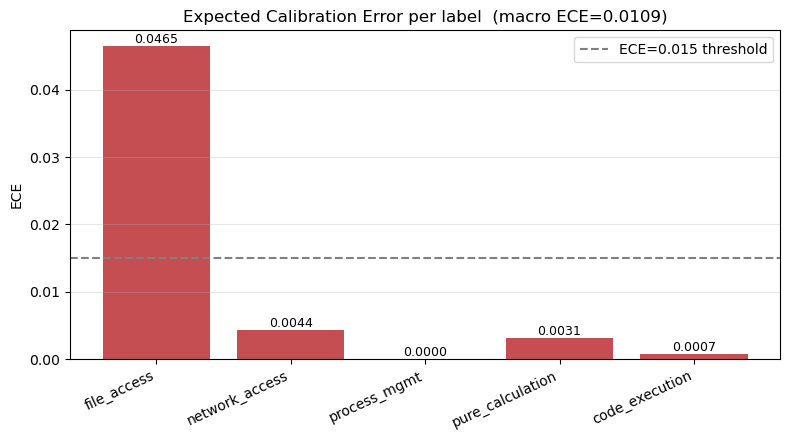

In [16]:
# Calibration — ECE per label + (if bin data available) reliability diagrams
import json, matplotlib.pyplot as plt
from pathlib import Path
R = json.load(open(Path('.').resolve() / 'outputs' / 'milestone3_results.json'))
LABELS = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']
cal = R['calibration']
has_bins = all(isinstance(cal.get(l, {}).get('bin_confidences'), list) for l in LABELS)

if has_bins:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()
    for i, lbl in enumerate(LABELS):
        c = cal[lbl]
        ax = axes[i]
        ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect')
        ax.plot(c['bin_confidences'], c['bin_accuracies'], 'o-', color='#4C72B0')
        ax.set_title(f'{lbl}  (ECE={c["ece"]:.4f})')
        ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
        ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=0.3)
    ax = axes[5]
    eces = [cal[l]['ece'] for l in LABELS]
    ax.bar(LABELS, eces, color='#C44E52')
    ax.set_xticklabels(LABELS, rotation=30, ha='right')
    ax.set_title(f'ECE per label  (macro ECE={cal["macro_ece"]:.4f})')
    ax.grid(axis='y', alpha=0.3)
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    eces = [cal[l]['ece'] for l in LABELS]
    bars = ax.bar(LABELS, eces, color='#C44E52')
    for b,v in zip(bars, eces): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticklabels(LABELS, rotation=25, ha='right')
    ax.axhline(0.015, ls='--', color='gray', label='ECE=0.015 threshold')
    ax.set_title(f'Expected Calibration Error per label  (macro ECE={cal["macro_ece"]:.4f})')
    ax.set_ylabel('ECE'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


#### 4. FAILURE CASE MINING

In [17]:
def mine_failures(model, test_dataset, device):
    """Find worst predictions for the failure table."""
    logger.info("\n" + "=" * 60)
    logger.info("4. FAILURE CASE MINING")
    logger.info("=" * 60)

    _, all_probs, all_labels = evaluate_dataset(model, test_dataset, device)
    preds = (all_probs > 0.5).astype(int)

    failures = []
    for i in range(len(test_dataset)):
        if not np.array_equal(preds[i], all_labels[i]):
            record = test_dataset.records[i]
            # Compute per-sample loss as severity
            loss = 0
            for j in range(5):
                loss += abs(all_probs[i][j] - all_labels[i][j])

            pred_labels = [LABELS[j] for j in range(5) if preds[i][j] == 1]
            true_labels = [LABELS[j] for j in range(5) if all_labels[i][j] == 1]
            max_conf = float(all_probs[i].max())

            failures.append({
                "index": i,
                "api_path": record.get("api_path", ""),
                "text_snippet": record.get("text", "")[:120],
                "predicted": pred_labels,
                "expected": true_labels,
                "probabilities": {LABELS[j]: round(float(all_probs[i][j]), 3) for j in range(5)},
                "max_confidence": round(max_conf, 3),
                "severity": round(float(loss), 3),
            })

    # Sort by severity
    failures.sort(key=lambda x: -x["severity"])

    # Take top 10
    top_failures = failures[:10]

    logger.info(f"  Total misclassified: {len(failures)}/{len(test_dataset)} ({len(failures)/len(test_dataset)*100:.1f}%)")
    for i, f in enumerate(top_failures):
        logger.info(f"  #{i+1}: {f['api_path'][:60]}")
        logger.info(f"       pred={f['predicted']}, true={f['expected']}, conf={f['max_confidence']}")

    return {"total_failures": len(failures), "total_samples": len(test_dataset), "top_failures": top_failures}

#### 5. LATENCY: CLEAN vs CORRUPTED

In [18]:
def run_latency_comparison(model, test_dataset, device, tokenizer):
    """Compare latency on clean vs corrupted inputs."""
    logger.info("\n" + "=" * 60)
    logger.info("5. LATENCY: CLEAN vs CORRUPTED")
    logger.info("=" * 60)

    results = {}

    for label, ds in [
        ("clean", test_dataset),
        ("token_dropout_0.2", StressTestedDataset(test_dataset, lambda ids: token_dropout(ids, 0.2))),
        ("char_noise_0.2", StressTestedDataset(test_dataset, lambda ids: char_noise(ids, 0.2, tokenizer.vocab_size))),
    ]:
        loader = DataLoader(ds, batch_size=64, shuffle=False)
        latencies = []

        # Warmup
        with torch.no_grad():
            for i, batch in enumerate(loader):
                if i >= 3: break
                model(batch["input_ids"].to(device), batch["length"].to(device))

        with torch.no_grad():
            for batch in loader:
                t0 = time.perf_counter()
                model(batch["input_ids"].to(device), batch["length"].to(device))
                if device.type == "cuda":
                    torch.cuda.synchronize()
                latencies.append((time.perf_counter() - t0) * 1000)

        arr = np.array(latencies)
        total_samples = len(ds)
        total_time = arr.sum() / 1000

        results[label] = {
            "batch64_p50_ms": round(float(np.percentile(arr, 50)), 2),
            "batch64_p90_ms": round(float(np.percentile(arr, 90)), 2),
            "throughput_samples_sec": round(total_samples / total_time, 1),
        }
        logger.info(f"  {label}: p50={results[label]['batch64_p50_ms']}ms, throughput={results[label]['throughput_samples_sec']}/sec")

    return results

#### 6. DRIFT SIMULATION + ADAPTATION

In [19]:
def run_drift_adaptation(model, test_dataset, tokenizer, device, data_dir):
    """Simulate distribution drift, then adapt model, report before/after."""
    logger.info("\n" + "=" * 60)
    logger.info("6. DRIFT SIMULATION + ADAPTATION")
    logger.info("=" * 60)

    results = {}

    # Load train data for adaptation
    train_dataset = APICallDataset(os.path.join(data_dir, "train.jsonl"), tokenizer)

    # Simulate drift: filter to only network/process heavy samples (rare classes)
    # This simulates a new codebase that is heavily distributed/RPC-focused
    logger.info("  Creating drifted dataset (network + process heavy)...")
    drift_indices = []
    for i, r in enumerate(test_dataset.records):
        labels = r.get("label_vector", [0]*5)
        # Keep if has network_access or process_mgmt
        if labels[1] == 1 or labels[2] == 1:
            drift_indices.append(i)
    # Also add some random pure_calculation to make it a real mix
    other_indices = [i for i in range(len(test_dataset)) if i not in set(drift_indices)]
    random.seed(42)
    random.shuffle(other_indices)
    drift_indices.extend(other_indices[:len(drift_indices) // 2])
    random.shuffle(drift_indices)

    drifted_test = Subset(test_dataset, drift_indices)
    logger.info(f"  Drifted test set: {len(drifted_test)} samples (vs {len(test_dataset)} original)")

    # Evaluate original model on drifted data
    logger.info("  Evaluating original model on drifted data...")
    before_res, _, _ = evaluate_dataset(model, drifted_test, device)
    results["before_adaptation"] = {
        "dataset_size": len(drifted_test),
        "macro_f1": before_res["macro_f1"],
        "exact_match": before_res["exact_match"],
        "per_label_f1": {name: before_res[name]["f1"] for name in LABELS},
    }
    logger.info(f"  Before: macro_f1={before_res['macro_f1']}")

    # Adaptation: fine-tune classifier head on a small sample of drift-like training data
    logger.info("  Fine-tuning classifier head on drift-like training subset...")
    # Select similar training samples
    drift_train_indices = []
    for i, r in enumerate(train_dataset.records):
        labels = r.get("label_vector", [0]*5)
        if labels[1] == 1 or labels[2] == 1:
            drift_train_indices.append(i)
    random.shuffle(drift_train_indices)
    drift_train_indices = drift_train_indices[:5000]  # small adaptation set

    drift_train = Subset(train_dataset, drift_train_indices)
    drift_loader = DataLoader(drift_train, batch_size=64, shuffle=True)

    # Copy model, freeze everything except classifier
    adapted_model = copy.deepcopy(model)
    for name, param in adapted_model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, adapted_model.parameters()),
        lr=5e-4, weight_decay=1e-4
    )
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([1.87, 1.55, 3.93, 0.44, 0.78]).to(device)
    )

    # Fine-tune for 3 epochs
    adapted_model.train()
    adapt_start = time.perf_counter()
    for epoch in range(3):
        total_loss = 0
        for batch in drift_loader:
            ids = batch["input_ids"].to(device)
            lens = batch["length"].to(device)
            labs = batch["labels"].to(device)
            optimizer.zero_grad()
            logits = adapted_model(ids, lens)
            loss = criterion(logits, labs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        logger.info(f"    Adaptation epoch {epoch+1}: loss={total_loss/len(drift_loader):.4f}")
    adapt_time = time.perf_counter() - adapt_start

    # Evaluate adapted model
    adapted_model.eval()
    logger.info("  Evaluating adapted model on drifted data...")
    after_res, _, _ = evaluate_dataset(adapted_model, drifted_test, device)
    results["after_adaptation"] = {
        "macro_f1": after_res["macro_f1"],
        "exact_match": after_res["exact_match"],
        "per_label_f1": {name: after_res[name]["f1"] for name in LABELS},
        "adaptation_time_sec": round(adapt_time, 1),
        "adaptation_samples": len(drift_train_indices),
        "adaptation_epochs": 3,
    }
    logger.info(f"  After: macro_f1={after_res['macro_f1']}")

    # Also check adapted model on ORIGINAL test set (ensure no regression)
    logger.info("  Checking adapted model on original test set...")
    orig_res, _, _ = evaluate_dataset(adapted_model, test_dataset, device)
    results["adapted_on_original"] = {
        "macro_f1": orig_res["macro_f1"],
        "exact_match": orig_res["exact_match"],
    }
    logger.info(f"  Adapted on original: macro_f1={orig_res['macro_f1']}")

    # Model size comparison
    orig_params = sum(p.numel() for p in model.parameters())
    adapted_params = sum(p.numel() for p in adapted_model.parameters())
    results["model_comparison"] = {
        "original_params": orig_params,
        "adapted_params": adapted_params,
        "params_changed": "classifier head only (same total params)",
    }

    return results

#### 7. MONITORING METRICS

In [20]:
def run_monitoring(model, test_dataset, device, data_dir, tokenizer):
    """Compute drift statistics simulating a monitoring scenario."""
    logger.info("\n" + "=" * 60)
    logger.info("7. MONITORING METRICS")
    logger.info("=" * 60)

    results = {}

    # Split test into "reference" (first half) and "current" (second half)
    n = len(test_dataset)
    ref_indices = list(range(0, n // 2))
    cur_indices = list(range(n // 2, n))

    ref_ds = Subset(test_dataset, ref_indices)
    cur_ds = Subset(test_dataset, cur_indices)

    # Evaluate both
    ref_res, ref_probs, ref_labels = evaluate_dataset(model, ref_ds, device)
    cur_res, cur_probs, cur_labels = evaluate_dataset(model, cur_ds, device)

    # PSI (Population Stability Index) for each label's predicted probability
    def compute_psi(ref_probs, cur_probs, n_bins=10):
        bins = np.linspace(0, 1, n_bins + 1)
        ref_hist = np.histogram(ref_probs, bins=bins)[0] / len(ref_probs)
        cur_hist = np.histogram(cur_probs, bins=bins)[0] / len(cur_probs)
        # Avoid log(0)
        ref_hist = np.clip(ref_hist, 1e-6, None)
        cur_hist = np.clip(cur_hist, 1e-6, None)
        psi = np.sum((cur_hist - ref_hist) * np.log(cur_hist / ref_hist))
        return round(float(psi), 6)

    psi_results = {}
    for i, name in enumerate(LABELS):
        psi = compute_psi(ref_probs[:, i], cur_probs[:, i])
        psi_results[name] = psi
        logger.info(f"  PSI({name}): {psi}")
    results["psi_per_label"] = psi_results

    # F1 comparison (simulating rolling window)
    results["reference_metrics"] = {
        "macro_f1": ref_res["macro_f1"],
        "exact_match": ref_res["exact_match"],
    }
    results["current_metrics"] = {
        "macro_f1": cur_res["macro_f1"],
        "exact_match": cur_res["exact_match"],
    }

    # Label distribution comparison
    ref_label_rates = ref_labels.mean(axis=0).tolist()
    cur_label_rates = cur_labels.mean(axis=0).tolist()
    results["label_rates"] = {
        "reference": {LABELS[i]: round(ref_label_rates[i], 4) for i in range(5)},
        "current": {LABELS[i]: round(cur_label_rates[i], 4) for i in range(5)},
    }

    # Confidence drift
    ref_max_conf = ref_probs.max(axis=1).mean()
    cur_max_conf = cur_probs.max(axis=1).mean()
    results["confidence_drift"] = {
        "reference_mean_max_conf": round(float(ref_max_conf), 4),
        "current_mean_max_conf": round(float(cur_max_conf), 4),
        "drift": round(float(cur_max_conf - ref_max_conf), 4),
    }
    logger.info(f"  Confidence drift: {results['confidence_drift']}")

    return results

#### MAIN

---
## Quick Reproduction Demo

The M3 experiment functions defined above (`run_stress_tests`, `run_adversarial`, `run_calibration`, `run_drift_adaptation`, `run_monitoring`) are invoked via the CLI below. Full run is **~10 min** with an existing checkpoint.

```bash
python scripts/milestone3_experiments.py \
    --data-dir ../milestone1_data/data/splits/training_data_fuzz \
    --checkpoint ../milestone2_model/checkpoints/best_model.pt \
    --tokenizer ../milestone2_model/checkpoints/tokenizer.json
```

The cell below summarizes the saved output so you can see the experiment's result structure without re-running.


In [21]:
# Demo: summarize the saved experiment output (regenerate via the CLI above, ~10 min).
import json
from pathlib import Path
R = json.load(open(Path('.').resolve() / 'outputs' / 'milestone3_results.json'))
LBL = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']

st   = R['stress_tests']
adv  = R['adversarial']
cal  = R['calibration']
da   = R['drift_adaptation']
mon  = R['monitoring']

print('═══════════════════ MILESTONE 3 EXPERIMENT SUMMARY ═══════════════════')
print(f'Clean baseline              macro F1 = {st["clean"]["macro_f1"]:.4f}')
print(f'Token dropout  5/10/20/30/50%:  ' + '  '.join(f'{st[f"token_dropout_{l}"]["macro_f1"]:.3f}' for l in [0.05,0.1,0.2,0.3,0.5]))
print(f'Char noise     5/10/20/30%  :   ' + '  '.join(f'{st[f"char_noise_{l}"]["macro_f1"]:.3f}'     for l in [0.05,0.1,0.2,0.3]))
print(f'Truncate      75/50/25%     :   ' + '  '.join(f'{st[f"truncate_{l}"]["macro_f1"]:.3f}'        for l in [0.75,0.5,0.25]))
print(f'FGSM ε=0.01/0.05/0.1/0.2/0.5:   ' + '  '.join(f'{adv[f"fgsm_eps_{e}"]["macro_f1"]:.3f}'        for e in [0.01,0.05,0.1,0.2,0.5]))
print()
print(f'Calibration (macro ECE)     = {cal["macro_ece"]:.4f}')
for l in LBL: print(f'   {l:<20} ECE = {cal[l]["ece"]:.4f}')
print()
print(f'Drift adaptation  before    = {da["before_adaptation"]["macro_f1"]:.4f}')
print(f'                  after     = {da["after_adaptation"]["macro_f1"]:.4f}')
print(f'                  Δ         = {da["after_adaptation"]["macro_f1"]-da["before_adaptation"]["macro_f1"]:+.4f}')
print(f'                  samples   = {da["after_adaptation"]["adaptation_samples"]}  epochs={da["after_adaptation"]["adaptation_epochs"]}  time={da["after_adaptation"]["adaptation_time_sec"]:.1f}s')
print()
print('Monitoring (PSI per label):')
for l in LBL: print(f'   {l:<20} PSI = {mon["psi_per_label"][l]:.5f}')
print(f'   reference macro F1={mon["reference_metrics"]["macro_f1"]:.4f}  current={mon["current_metrics"]["macro_f1"]:.4f}')


═══════════════════ MILESTONE 3 EXPERIMENT SUMMARY ═══════════════════
Clean baseline              macro F1 = 0.9788
Token dropout  5/10/20/30/50%:  0.975  0.969  0.956  0.940  0.909
Char noise     5/10/20/30%  :   0.950  0.902  0.830  0.757
Truncate      75/50/25%     :   0.928  0.882  0.274
FGSM ε=0.01/0.05/0.1/0.2/0.5:   0.976  0.982  0.976  0.976  0.457

Calibration (macro ECE)     = 0.0109
   file_access          ECE = 0.0465
   network_access       ECE = 0.0044
   process_mgmt         ECE = 0.0000
   pure_calculation     ECE = 0.0031
   code_execution       ECE = 0.0007

Drift adaptation  before    = 0.9442
                  after     = 0.9632
                  Δ         = +0.0190
                  samples   = 5000  epochs=3  time=6.3s

Monitoring (PSI per label):
   file_access          PSI = 0.18400
   network_access       PSI = 0.00160
   process_mgmt         PSI = 0.00250
   pure_calculation     PSI = 0.01160
   code_execution       PSI = 0.00240
   reference macro F1=0.9788 

---
## Visual Results — Plots from `outputs/milestone3_results.json`


In [22]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path('.').resolve() / 'outputs' / 'milestone3_results.json'
R = json.load(open(RESULTS))
LABELS = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']
print(f'Loaded: {RESULTS}')
print('Sections:', list(R.keys()))


Loaded: /home/kramer/Projects/AIRoom/milestones/milestone3_robustness/outputs/milestone3_results.json
Sections: ['stress_tests', 'adversarial', 'calibration', 'monitoring', 'drift_adaptation', '_provenance']


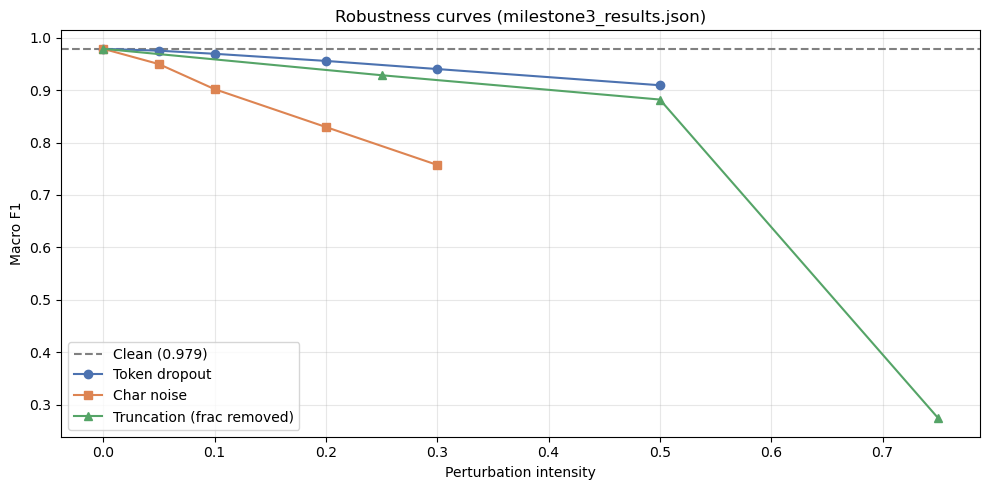

In [23]:
# Robustness curves: token dropout, char noise, truncation
st = R['stress_tests']
clean = st['clean']['macro_f1']
td_levels = [0.05, 0.1, 0.2, 0.3, 0.5]
td_f1 = [st[f'token_dropout_{l}']['macro_f1'] for l in td_levels]
cn_levels = [0.05, 0.1, 0.2, 0.3]
cn_f1 = [st[f'char_noise_{l}']['macro_f1'] for l in cn_levels]
tr_levels = [0.75, 0.5, 0.25]
tr_f1 = [st[f'truncate_{l}']['macro_f1'] for l in tr_levels]

fig, ax = plt.subplots(figsize=(10,5))
ax.axhline(clean, ls='--', color='grey', label=f'Clean ({clean:.3f})')
ax.plot([0]+td_levels, [clean]+td_f1, 'o-', label='Token dropout',  color='#4C72B0')
ax.plot([0]+cn_levels, [clean]+cn_f1, 's-', label='Char noise',     color='#DD8452')
ax.plot([0]+[1-x for x in tr_levels], [clean]+tr_f1, '^-', label='Truncation (frac removed)', color='#55A467')
ax.set_xlabel('Perturbation intensity'); ax.set_ylabel('Macro F1')
ax.set_title('Robustness curves (milestone3_results.json)')
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()


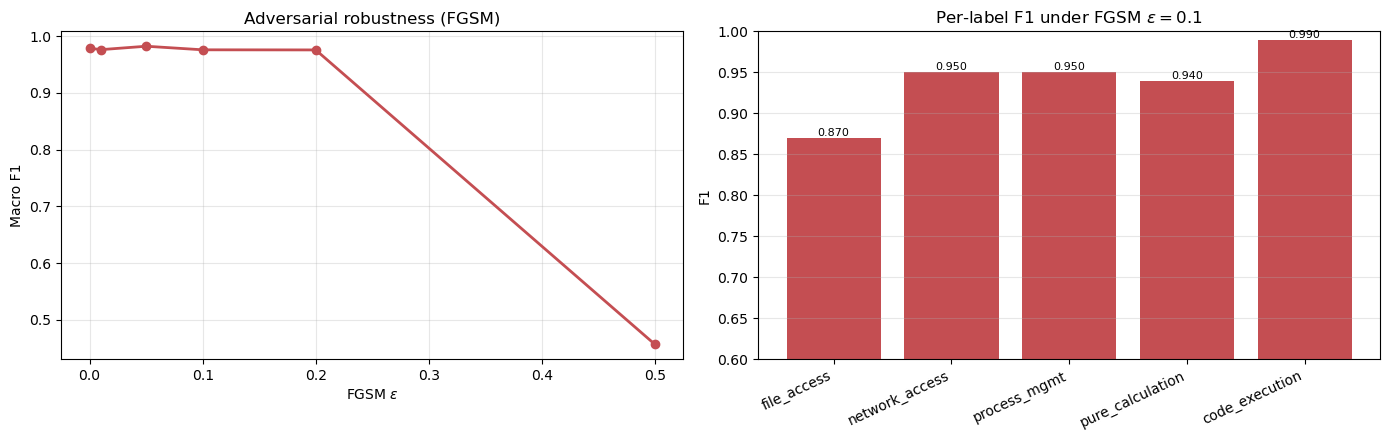

In [24]:
# Adversarial FGSM curve + per-label at worst budget
adv = R['adversarial']
eps = [0.01, 0.05, 0.1, 0.2, 0.5]
adv_f1 = [adv[f'fgsm_eps_{e}']['macro_f1'] for e in eps]

fig, axes = plt.subplots(1, 2, figsize=(14,4.5))
ax = axes[0]
ax.plot([0]+eps, [R['stress_tests']['clean']['macro_f1']]+adv_f1, 'o-', color='#C44E52', lw=2)
ax.set_xlabel(r'FGSM $\epsilon$'); ax.set_ylabel('Macro F1')
ax.set_title('Adversarial robustness (FGSM)')
ax.grid(alpha=0.3)

# Per-label F1 at eps=0.1
per = adv['fgsm_eps_0.1']['per_label_f1']
ax = axes[1]
bars = ax.bar(LABELS, [per[l] for l in LABELS], color='#C44E52')
for b,v in zip(bars, [per[l] for l in LABELS]): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_ylim(0.6, 1.0); ax.set_ylabel('F1')
ax.set_title(r'Per-label F1 under FGSM $\epsilon=0.1$')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


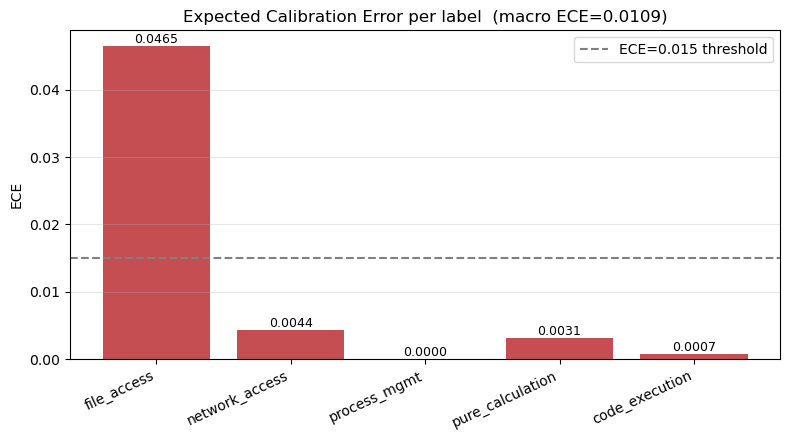

In [25]:
# Calibration — ECE per label + (if bin data available) reliability diagrams
import json, matplotlib.pyplot as plt
from pathlib import Path
R = json.load(open(Path('.').resolve() / 'outputs' / 'milestone3_results.json'))
LABELS = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']
cal = R['calibration']
has_bins = all(isinstance(cal.get(l, {}).get('bin_confidences'), list) for l in LABELS)

if has_bins:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()
    for i, lbl in enumerate(LABELS):
        c = cal[lbl]
        ax = axes[i]
        ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect')
        ax.plot(c['bin_confidences'], c['bin_accuracies'], 'o-', color='#4C72B0')
        ax.set_title(f'{lbl}  (ECE={c["ece"]:.4f})')
        ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
        ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=0.3)
    ax = axes[5]
    eces = [cal[l]['ece'] for l in LABELS]
    ax.bar(LABELS, eces, color='#C44E52')
    ax.set_xticklabels(LABELS, rotation=30, ha='right')
    ax.set_title(f'ECE per label  (macro ECE={cal["macro_ece"]:.4f})')
    ax.grid(axis='y', alpha=0.3)
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    eces = [cal[l]['ece'] for l in LABELS]
    bars = ax.bar(LABELS, eces, color='#C44E52')
    for b,v in zip(bars, eces): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=25, ha='right')
    ax.axhline(0.015, ls='--', color='gray', label='ECE=0.015 threshold')
    ax.set_title(f'Expected Calibration Error per label  (macro ECE={cal["macro_ece"]:.4f})')
    ax.set_ylabel('ECE'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


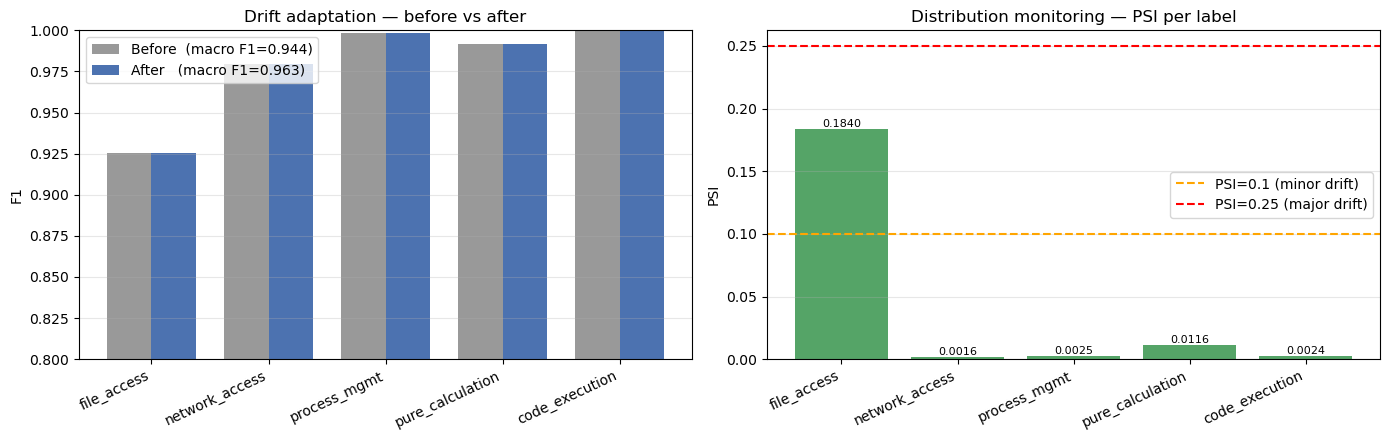

In [26]:
# Drift adaptation + monitoring PSI
da = R['drift_adaptation']
mon = R['monitoring']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
before = [da['before_adaptation']['per_label_f1'][l] for l in LABELS]
after  = [da['after_adaptation']['per_label_f1'][l]  for l in LABELS]
x = np.arange(len(LABELS)); w = 0.38
ax.bar(x-w/2, before, w, label=f'Before  (macro F1={da["before_adaptation"]["macro_f1"]:.3f})', color='#999999')
ax.bar(x+w/2, after,  w, label=f'After   (macro F1={da["after_adaptation"]["macro_f1"]:.3f})', color='#4C72B0')
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_ylim(0.8, 1.0); ax.set_ylabel('F1'); ax.set_title('Drift adaptation — before vs after')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
psi = [mon['psi_per_label'][l] for l in LABELS]
bars = ax.bar(LABELS, psi, color='#55A467')
for b,v in zip(bars,psi): ax.text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.axhline(0.1, ls='--', color='orange', label='PSI=0.1 (minor drift)')
ax.axhline(0.25, ls='--', color='red', label='PSI=0.25 (major drift)')
ax.set_title('Distribution monitoring — PSI per label')
ax.set_ylabel('PSI'); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
